In [1]:
import torch
from torch_geometric.data import HeteroData

data: HeteroData = torch.load("data/graph/hetero_sdge.pt",weights_only=False)
data

HeteroData(
  tasks={
    x=[5401876, 149],
    w6key=[5401876],
  },
  assignments={
    x=[3716388, 118],
    task_id=[3716388],
  },
  engineers={ x=[22716, 126] },
  districts={
    x=[316, 120],
    w6key=[316],
  },
  (tasks, tasks_to_assignments, assignments)={ edge_index=[2, 3685018] },
  (assignments, assignments_to_tasks, tasks)={ edge_index=[2, 3685018] },
  (tasks, tasks_to_districts, districts)={ edge_index=[2, 5401561] },
  (districts, districts_to_tasks, tasks)={ edge_index=[2, 5401561] },
  (assignments, assignments_to_engineers, engineers)={ edge_index=[2, 3605417] },
  (engineers, engineers_to_assignments, assignments)={ edge_index=[2, 3605417] },
  (engineers, engineers_to_districts, districts)={ edge_index=[2, 22622] },
  (districts, districts_to_engineers, engineers)={ edge_index=[2, 22622] }
)

In [4]:
data["tasks"]

{'x': tensor([[2.2608e+05, 1.0000e+00, 1.0000e+01,  ..., 0.0000e+00, 0.0000e+00,
         1.0000e+00],
        [1.8000e+03, 1.0000e+00, 3.0000e+01,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [6.7680e+04, 1.0000e+00, 1.2000e+01,  ..., 0.0000e+00, 0.0000e+00,
         1.0000e+00],
        ...,
        [2.8800e+03, 1.0000e+01, 2.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         1.0000e+00],
        [1.4400e+04, 1.0000e+01, 2.7000e+01,  ..., 0.0000e+00, 0.0000e+00,
         1.0000e+00],
        [1.4400e+04, 1.0000e+01, 1.8000e+01,  ..., 0.0000e+00, 0.0000e+00,
         1.0000e+00]]), 'w6key': tensor([2761188, 2750492, 2807890,  ..., 4273253, 2735906, 2618565])}

In [2]:
from pathlib import Path
import pandas as pd

FEATURE_DIR = Path("data/features_table")

task_feat_clean = pd.read_parquet(FEATURE_DIR / "task_feat_clean.parquet")
assignment_feat_clean = pd.read_parquet(FEATURE_DIR / "assignment_feat_clean.parquet")
engineer_feat_clean = pd.read_parquet(FEATURE_DIR / "engineer_feat_clean.parquet")
district_feat_clean = pd.read_parquet(FEATURE_DIR / "district_feat_clean.parquet")

print(task_feat_clean.shape, assignment_feat_clean.shape)
print(task_feat_clean.head())

(5401876, 154) (3716388, 120)
     W6KEY     STATUS  TASKTYPE  DISTRICT   DEPARTMENT  task_DURATION  \
0  2761188  124131328      1272       156  126763008.0         226080   
1  2750492  124131328      1386       119  126763008.0           1800   
2  2807890  124131328      1273       155  126763008.0          67680   
3  2159862  124131328      1277       152  126763008.0          16920   
4  2028705  124133377      1270       132  126763008.0           6840   

   task_TASKNUMBER  task_DISPLAYDATE_day  task_DISPLAYDATE_day_cos  \
0                1                  10.0                 -0.440394   
1                1                  30.0                   0.97953   
2                1                  12.0                 -0.758758   
3                1                   5.0                  0.528964   
4                1                   5.0                  0.528964   

   task_DISPLAYDATE_day_sin  ...  task_CITY_RIVERSIDE  task_CITY_SAN DIEGO  \
0                  0.897805  ...

In [3]:
for ntype in data.node_types:
    num_nodes = data[ntype].num_nodes
    deg_in = torch.zeros(num_nodes, dtype=torch.long)
    deg_out = torch.zeros(num_nodes, dtype=torch.long)

    print(f"\n=== Node type: {ntype} (num_nodes={num_nodes}) ===")

    for srctype, etype, dsttype in data.edge_types:
        edge_index = data[(srctype, etype, dsttype)].edge_index

        # 出度：源是当前 ntype
        if srctype == ntype:
            max_idx = int(edge_index[0].max())
            if max_idx >= num_nodes:
                print(
                    f"[WARN] out-of-range src index in edge "
                    f"{(srctype, etype, dsttype)}: max_idx={max_idx}, num_nodes={num_nodes}"
                )
            minlength = max(num_nodes, max_idx + 1)
            d = torch.bincount(edge_index[0], minlength=minlength)
            deg_out += d[:num_nodes]

        # 入度：目标是当前 ntype
        if dsttype == ntype:
            max_idx = int(edge_index[1].max())
            if max_idx >= num_nodes:
                print(
                    f"[WARN] out-of-range dst index in edge "
                    f"{(srctype, etype, dsttype)}: max_idx={max_idx}, num_nodes={num_nodes}"
                )
            minlength = max(num_nodes, max_idx + 1)
            d = torch.bincount(edge_index[1], minlength=minlength)
            deg_in += d[:num_nodes]

    print("  in-degree mean:", deg_in.float().mean().item())
    print("  out-degree mean:", deg_out.float().mean().item())
    print("  zero in-degree ratio:", (deg_in == 0).float().mean().item())
    print("  zero out-degree ratio:", (deg_out == 0).float().mean().item())


=== Node type: tasks (num_nodes=5401876) ===
  in-degree mean: 1.6821154356002808
  out-degree mean: 1.6821154356002808
  zero in-degree ratio: 5.83130749873817e-05
  zero out-degree ratio: 5.83130749873817e-05

=== Node type: assignments (num_nodes=3716388) ===
  in-degree mean: 1.96169912815094
  out-degree mean: 1.96169912815094
  zero in-degree ratio: 0.0010289560304954648
  zero out-degree ratio: 0.0010289560304954648

=== Node type: engineers (num_nodes=22716) ===
  in-degree mean: 159.7129364013672
  out-degree mean: 159.7129364013672
  zero in-degree ratio: 0.0036538122221827507
  zero out-degree ratio: 0.0036538122221827507

=== Node type: districts (num_nodes=316) ===
  in-degree mean: 17165.13671875
  out-degree mean: 17165.13671875
  zero in-degree ratio: 0.10443037748336792
  zero out-degree ratio: 0.10443037748336792


In [41]:
import torch
import pandas as pd
import numpy as np

# ============================================
# 1. 从 data 里抽 task 的 degree 特征
# ============================================
def add_task_degree_features(data, task_df: pd.DataFrame) -> pd.DataFrame:
    num_tasks = data["tasks"].num_nodes

    # task → assignments
    if ("tasks", "tasks_to_assignments", "assignments") in data.edge_types:
        ei_ta = data[("tasks", "tasks_to_assignments", "assignments")].edge_index
        deg_assign = torch.bincount(ei_ta[0], minlength=num_tasks)
    else:
        deg_assign = torch.zeros(num_tasks, dtype=torch.long)

    # task → districts
    if ("tasks", "tasks_to_districts", "districts") in data.edge_types:
        ei_td = data[("tasks", "tasks_to_districts", "districts")].edge_index
        deg_district = torch.bincount(ei_td[0], minlength=num_tasks)
    else:
        deg_district = torch.zeros(num_tasks, dtype=torch.long)

    df = task_df.copy()
    df["deg_assign"] = deg_assign.numpy()
    df["deg_district"] = deg_district.numpy()
    return df


task_with_deg = add_task_degree_features(data, task_feat_clean)

# ============================================
# 2. 轻量版相关性分析（子采样 + Pearson）
# ============================================

# 所有数值列 + 两个 degree 列
num_cols = task_feat_clean.select_dtypes(include=["number", "bool"]).columns.tolist()
cols_for_corr = num_cols + ["deg_assign", "deg_district"]

N = len(task_with_deg)
N_SAMPLE = min(N, 200_000)  # 子样本大小，你可以改大一点，比如 500_000

rng = np.random.default_rng(42)
idx = rng.choice(N, size=N_SAMPLE, replace=False)
sample = task_with_deg.iloc[idx]

# 快速版：Pearson 相关
corr_pearson = sample[cols_for_corr].corr(method="pearson")

print("\nPearson corr with deg_assign / deg_district (sampled):")
print(
    corr_pearson[["deg_assign", "deg_district"]]
    .sort_values("deg_assign", ascending=False)
    .head(30)
)

# 如果你坚持要 Spearman，只在子样本上算（会慢一些，但远比全量好得多）
# corr_spearman = sample[cols_for_corr].corr(method="spearman")
# print(corr_spearman[["deg_assign", "deg_district"]]
#       .sort_values("deg_assign", ascending=False)
#       .head(30))

# ============================================
# 3. District 上的 Laplacian-based smoothness
# ============================================

def build_knn_graph(x: torch.Tensor, k: int = 5) -> torch.Tensor:
    """
    在 feature 空间上对 nodes 建 kNN 图：
      - x: [N, d]
      - 返回 edge_index: [2, E]
    这里 N=316 左右，暴力 torch.cdist 没问题。
    """
    N = x.size(0)
    dist = torch.cdist(x, x)  # [N, N]
    knn_dist, knn_idx = dist.topk(k + 1, largest=False)
    knn_idx = knn_idx[:, 1:]  # 去掉自己，变成 [N, k]

    src = torch.arange(N).unsqueeze(1).expand(-1, k).reshape(-1)
    dst = knn_idx.reshape(-1)
    edge_index = torch.stack([src, dst], dim=0)
    return edge_index


def laplacian_smoothness(x: torch.Tensor, edge_index: torch.Tensor) -> float:
    """
    S(x) = 1/|E| * Σ_{(i,j)∈E} ||x_i - x_j||^2
    """
    src, dst = edge_index
    diff = x[src] - x[dst]      # [E, d]
    sq = (diff ** 2).sum(dim=1) # [E]
    return sq.mean().item()


# 在 districts 上搞 smoothness
x_dist = data["districts"].x  # [num_districts, d]
edge_index_knn = build_knn_graph(x_dist, k=5)

smooth_all = laplacian_smoothness(x_dist, edge_index_knn)
print("\nDistrict features overall Laplacian smoothness (kNN graph, k=5):", smooth_all)

# 看每一维的平滑度（便于挑“更图结构友好”的 feature）
smooth_per_dim = []
for dim in range(x_dist.size(1)):
    s = laplacian_smoothness(x_dist[:, dim : dim + 1], edge_index_knn)
    smooth_per_dim.append(s)

smooth_per_dim = torch.tensor(smooth_per_dim)
print("Per-dimension smoothness (first 20 dims):")
print(smooth_per_dim[:20])


Pearson corr with deg_assign / deg_district (sampled):
                           deg_assign  deg_district
deg_assign                   1.000000  7.374320e-03
task_OPENDATE_year           0.658636           NaN
task_SCHEDULEDFINISH_year    0.656353 -1.121269e-02
task_SCHEDULEDSTART_year     0.656187 -1.121725e-02
task_METRICDATE_year         0.655150 -4.750553e-03
task_DISPLAYDATE_hour        0.654792  2.472902e-03
task_DUEDATE_year            0.632287 -4.426075e-03
task_EARLYSTART_year         0.624109 -5.844236e-03
task_LATESTART_year          0.487799 -1.043820e-02
task_TIMECREATED_year        0.463028 -1.042168e-02
TASKTYPE                     0.433354  8.566434e-03
DISTRICT                     0.417673           NaN
W6KEY                        0.406056 -1.198331e-02
task_DISPLAYDATE_year        0.381134 -1.028174e-02
task_REGION_16               0.242381  2.382840e-03
task_REGION_21               0.201325  1.957551e-03
task_REGION_22               0.200497  1.938470e-03
task_REG

In [49]:
corr_pearson["deg_assign"].sort_values(ascending=False).head(40)

deg_assign                           1.000000
task_OPENDATE_year                   0.658636
task_SCHEDULEDFINISH_year            0.656353
task_SCHEDULEDSTART_year             0.656187
task_METRICDATE_year                 0.655150
task_DISPLAYDATE_hour                0.654792
task_DUEDATE_year                    0.632287
task_EARLYSTART_year                 0.624109
task_LATESTART_year                  0.487799
task_TIMECREATED_year                0.463028
TASKTYPE                             0.433354
DISTRICT                             0.417673
W6KEY                                0.406056
task_DISPLAYDATE_year                0.381134
task_REGION_16                       0.242381
task_REGION_21                       0.201325
task_REGION_22                       0.200497
task_REGION_20                       0.191114
task_REGION_17                       0.103368
task_REGION_14                       0.098108
task_REGION_18                       0.097035
task_EARLYSTART_hour              

In [5]:
import numpy as np
import torch


def build_engineer_coassignment_edges(
    data,
    max_pairs_per_assign: int = 10,
) -> torch.Tensor:
    """
    基于异质图 data 里 assignments–engineers 的关系，
    构造 engineer–engineer 共工图的 edge_index。

    逻辑：
      - 对每个 assignment，把参与的 engineers 收集成列表
      - 在同一个 assignment 内，对 engineer 做采样成若干 pair
      - 输出 edge_index: [2, E], 无向图（每对只加一条边）
    """
    ei_ae = data[("assignments", "assignments_to_engineers", "engineers")].edge_index
    num_assign = data["assignments"].num_nodes

    # assignment -> engineers 列表
    eng_lists = [[] for _ in range(num_assign)]
    src = ei_ae[0].cpu().numpy()
    dst = ei_ae[1].cpu().numpy()
    for a, e in zip(src, dst):
        eng_lists[a].append(int(e))

    rng = np.random.default_rng(0)
    edges = []

    for engs in eng_lists:
        # 去重
        engs = list(set(engs))
        n = len(engs)
        if n < 2:
            continue

        # 理论最大 pair 数
        max_pairs = n * (n - 1) // 2
        k = min(max_pairs, max_pairs_per_assign)

        # 全部列举 or 采样
        if max_pairs <= max_pairs_per_assign:
            for i in range(n):
                for j in range(i + 1, n):
                    u, v = engs[i], engs[j]
                    edges.append((u, v))
        else:
            # 随机采样 k 个 pair
            for _ in range(k):
                i, j = rng.choice(n, size=2, replace=False)
                u, v = engs[i], engs[j]
                if u == v:
                    continue
                if u > v:
                    u, v = v, u
                edges.append((u, v))

    if not edges:
        raise RuntimeError("No engineer–engineer edges constructed.")

    # 去重 & 转 tensor
    edges = list(set(edges))
    edges_arr = torch.tensor(edges, dtype=torch.long).t().contiguous()  # [2, E]

    return edges_arr

build_engineer_coassignment_edges(data)

tensor([[17685, 19268, 18740,  ...,  4178, 21350, 16275],
        [18371, 18541, 20142,  ...,  4773, 20524, 15532]])

In [42]:
engineer_feat_clean

,NAME,DISTRICT,DEPARTMENT,eng_EFFICIENCY,eng_TIMECREATED_day,eng_TIMECREATED_day_cos,eng_TIMECREATED_day_sin,eng_TIMECREATED_hour,eng_TIMECREATED_hour_cos,eng_TIMECREATED_hour_sin,...,eng_ENGINEERTYPE_46,eng_ENGINEERTYPE_5,eng_ENGINEERTYPE_51,eng_ENGINEERTYPE_7,eng_ENGINEERTYPE_86,eng_ENGINEERTYPE_89,eng_ENGINEERTYPE_90,eng_ENGINEERTYPE_92,eng_ENGINEERTYPE_95,eng_ENGINEERTYPE___OTHER__
0,CT_1_GLN_HAAS,83,126763008.0,0.0,10.0,-0.440394,0.897805,11.0,-0.965926,0.258819,...,0,0,0,0,0,0,0,0,0,1
1,LCT_2_OXN_MYERS,83,126763008.0,0.0,10.0,-0.440394,0.897805,11.0,-0.965926,0.258819,...,0,1,0,0,0,0,0,0,0,0
2,CT_1_GLN_CRUZ,83,126763008.0,0.0,10.0,-0.440394,0.897805,11.0,-0.965926,0.258819,...,0,0,0,0,0,0,0,0,0,1
3,RECONCILIATION BUCKET,33,126763010.0,0.0,9.0,-0.250653,0.968077,14.0,-0.866025,-0.5,...,0,0,0,0,0,0,0,0,0,0
4,LCT_2_LNC_MCWILLIAMS,83,126763008.0,0.0,9.0,-0.250653,0.968077,10.0,-0.866025,0.5,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22711,LCT_BRN_BALBOA,209,1166016513.0,0.0,14.0,-0.954139,0.299363,12.0,-1.0,0.0,...,0,0,0,0,0,0,0,0,0,0
22712,LS_PMD_CORONEL,233,1166016513.0,0.0,8.0,-0.050649,0.998717,9.0,-0.707107,0.707107,...,0,0,0,0,0,0,0,0,0,0
22713,BC_WFE_OVERTIME_4X,182,126763010.0,0.0,24.0,0.151428,-0.988468,4.0,0.5,0.866025,...,0,0,0,0,0,0,0,0,0,1
22714,ESS_FHS_TESTCREW_LARS,183,126763012.0,0.0,24.0,0.151428,-0.988468,4.0,0.5,0.866025,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import torch
engineer_feat_clean

def compute_smoothness(
    edge_index: torch.Tensor,
    x: torch.Tensor,
    max_edges: int | None = 200_000,
):
    """
    在 edge_index 上计算 feature smoothness:
      对每条边 (i, j), 计算 (x_i - x_j)^2，先对边平均，再对维度取均值。

    返回:
      per_dim: [F]，每一维的 smoothness
      scalar:  float，总的平均 smoothness
    """
    assert edge_index.shape[0] == 2
    E = edge_index.shape[1]

    if max_edges is not None and E > max_edges:
        idx = torch.randperm(E, device=edge_index.device)[:max_edges]
        ei = edge_index[:, idx]
    else:
        ei = edge_index

    src, dst = ei[0], ei[1]

    diff = x[src] - x[dst]          # [E, F]
    sq = diff.pow(2)                # [E, F]
    per_dim = sq.mean(dim=0)        # [F]
    scalar = per_dim.mean().item()  # 标量

    return per_dim, scalar


def compare_real_vs_random_smoothness(
    edge_index: torch.Tensor,
    x: torch.Tensor,
    *,
    num_random: int = 5,
    max_edges: int | None = 200_000,
):
    """
    比较:
      - 真实图上的 smoothness
      - 同样节点数 & 边数、端点随机连的 baseline smoothness（多次取平均）
    """
    device = x.device
    num_nodes = x.shape[0]
    E = edge_index.shape[1]

    # 1) 真实图 smoothness
    real_per_dim, real_scalar = compute_smoothness(edge_index, x, max_edges=max_edges)

    # 2) 随机图 smoothness
    rand_per_dim_list = []
    rand_scalar_list = []

    for _ in range(num_random):
        src_rand = torch.randint(0, num_nodes, (E,), device=device)
        dst_rand = torch.randint(0, num_nodes, (E,), device=device)
        edge_rand = torch.stack([src_rand, dst_rand], dim=0)

        per_dim_r, scalar_r = compute_smoothness(edge_rand, x, max_edges=max_edges)
        rand_per_dim_list.append(per_dim_r)
        rand_scalar_list.append(scalar_r)

    rand_per_dim_mean = torch.stack(rand_per_dim_list, dim=0).mean(dim=0)
    rand_scalar_mean = float(sum(rand_scalar_list) / len(rand_scalar_list))

    return real_per_dim, real_scalar, rand_per_dim_mean, rand_scalar_mean

num_cols = engineer_feat_clean.select_dtypes(include=["number"]).columns.tolist()
edge_index_eng = build_engineer_coassignment_edges(data, max_pairs_per_assign=10)

# 2) 拿 engineer 的特征（已经是你 feature_table 之后的 x）
x_eng = data["engineers"].x  # [num_engineers, F]

# 3) 比较真实 vs 随机 smoothness
real_per_dim, real_scalar, rand_per_dim_mean, rand_scalar_mean = \
    compare_real_vs_random_smoothness(
        edge_index_eng,
        x_eng,
        num_random=5,
        max_edges=200_000,  # 再大你自己看内存
    )

print("Engineer graph smoothness (scalar):")
print("  real :", real_scalar)
print("  rand :", rand_scalar_mean)

print("\nFirst 20 dims (real vs random):")
for i in range(min(30, real_per_dim.numel())):
    print(
        f"dim {i:02d}:real={real_per_dim[i].item():.6f}, "
        f"rand={rand_per_dim_mean[i].item():.6f}"
    )

Engineer graph smoothness (scalar):
  real : 1.907800555229187
  rand : 3.5932521343231203

First 20 dims (real vs random):
dim 00:real=0.124882, rand=6.102204
dim 01:real=54.439541, rand=118.784386
dim 02:real=0.371603, rand=0.715864
dim 03:real=0.500190, rand=0.995695
dim 04:real=22.983877, rand=40.980400
dim 05:real=0.538429, rand=0.732684
dim 06:real=0.383312, rand=0.696690
dim 07:real=9.993212, rand=17.773186
dim 08:real=0.537025, rand=0.965040
dim 09:real=0.460604, rand=0.911840
dim 10:real=15.274502, rand=39.323971
dim 11:real=86.189224, rand=121.509804
dim 12:real=0.519543, rand=0.986248
dim 13:real=0.523184, rand=0.899027
dim 14:real=22.338566, rand=43.454220
dim 15:real=0.288707, rand=0.728182
dim 16:real=0.556908, rand=0.792678
dim 17:real=10.907085, rand=18.860332
dim 18:real=0.501451, rand=0.892020
dim 19:real=0.545864, rand=1.028403
dim 20:real=9.069580, rand=27.140860
dim 21:real=0.001273, rand=0.004328
dim 22:real=0.004243, rand=0.009164
dim 23:real=0.030123, rand=0.108

In [ ]:
import torch
import numpy as np


def moran_I_1d(
    edge_index: torch.Tensor,
    x: torch.Tensor,
    max_edges: int | None = 200_000,
):
    """
    计算单维特征 x 在给定图 (edge_index) 上的 Moran's I.

    edge_index: [2, E]
    x: [N]
    """
    assert edge_index.shape[0] == 2
    x = x.float()

    # Optional: subsample edges for speed
    E = edge_index.shape[1]
    if max_edges is not None and E > max_edges:
        idx = torch.randperm(E, device=edge_index.device)[:max_edges]
        ei = edge_index[:, idx]
    else:
        ei = edge_index

    src, dst = ei[0], ei[1]
    N = x.shape[0]
    W = ei.shape[1]

    x_mean = x.mean()
    x_c = x - x_mean

    num = (x_c[src] * x_c[dst]).sum()
    den = (x_c ** 2).sum()

    I = (N / W) * (num / den)
    return float(I)



def moran_I_all_dims(
    edge_index: torch.Tensor,
    X: torch.Tensor,
    max_edges: int | None = 200_000,
) -> torch.Tensor:
    """
    X: [N, F] 多维特征矩阵
    返回: [F] 每一维的 Moran's I
    """
    assert X.dim() == 2
    N, F = X.shape
    X = X.float()

    E = edge_index.shape[1]
    if max_edges is not None and E > max_edges:
        idx = torch.randperm(E, device=edge_index.device)[:max_edges]
        ei = edge_index[:, idx]
    else:
        ei = edge_index

    src, dst = ei[0], ei[1]
    W = ei.shape[1]

    X_mean = X.mean(dim=0, keepdim=True)
    Xc = X - X_mean

    v_src = Xc[src]          # [E, F]
    v_dst = Xc[dst]          # [E, F]

    num = (v_src * v_dst).sum(dim=0)   # [F]
    den = (Xc ** 2).sum(dim=0)         # [F]

    I = (N / W) * (num / den)
    return I


def moran_I_permutation_test(
    edge_index: torch.Tensor,
    x: torch.Tensor,
    *,
    n_perm: int = 200,
    max_edges: int | None = 200_000,
) -> dict:
    """
    permutation test：
      - I_obs：真实 Moran’s I
      - I_perm：置换后的分布
      - z-score, p-value
    """
    device = x.device
    N = x.shape[0]

    I_obs = moran_I_1d(edge_index, x, max_edges=max_edges)

    I_perm_list = []
    for _ in range(n_perm):
        perm = torch.randperm(N, device=device)
        x_perm = x[perm]
        I_p = moran_I_1d(edge_index, x_perm, max_edges=max_edges)
        I_perm_list.append(I_p)

    I_perm = torch.tensor(I_perm_list)
    mean_perm = float(I_perm.mean())
    std_perm = float(I_perm.std(unbiased=True))
    
    z = (I_obs - mean_perm) / (std_perm + 1e-12)
    p_right = float(((I_perm >= I_obs).sum().item() + 1) / (n_perm + 1))

    return {
        "I_obs": I_obs,
        "I_perm": I_perm_list,
        "mean_perm": mean_perm,
        "std_perm": std_perm,
        "z": z,
        "p_right": p_right,
    }



x_eng = data["engineers"].x  # [N_eng, F]
edge_index = edge_index_eng.to(x_eng.device)

I_all = moran_I_all_dims(edge_index, x_eng, max_edges=200_000)

print("=== Moran's I (first 20 dims) ===")
for i in range(min(20, I_all.numel())):
    print(f"dim {i:02d}: I = {I_all[i].item():.4f}")

x_1d = x_eng[:, 0]
res = moran_I_permutation_test(
    edge_index=edge_index,
    x=x_1d,
    n_perm=200,
    max_edges=200_000,
)

print("\n=== Moran's I permutation test (dim 0) ===")
for k, v in res.items():
    if k == "I_perm":
        continue
    print(f"{k}: {v}")


=== Moran's I (first 20 dims) ===
dim 00: I = 1.9508
dim 01: I = 0.4422
dim 02: I = 0.3073
dim 03: I = 0.4948
dim 04: I = 0.4379
dim 05: I = 0.3869
dim 06: I = 0.4018
dim 07: I = 0.5812
dim 08: I = 0.4283
dim 09: I = 0.4495
dim 10: I = 0.3599
dim 11: I = 0.3684
dim 12: I = 0.5687
dim 13: I = 0.2937
dim 14: I = 0.3340
dim 15: I = 0.3709
dim 16: I = 0.3714
dim 17: I = 0.3439
dim 18: I = 0.4888
dim 19: I = 0.3514

=== Moran's I permutation test (dim 0) ===
I_obs: 1.9508259296417236
mean_perm: 9.962543845176697e-05
std_perm: 0.005369390826672316
z: 363.304957081869
p_right: 0.004975124378109453


LCC size: 8, small-components total nodes: 78


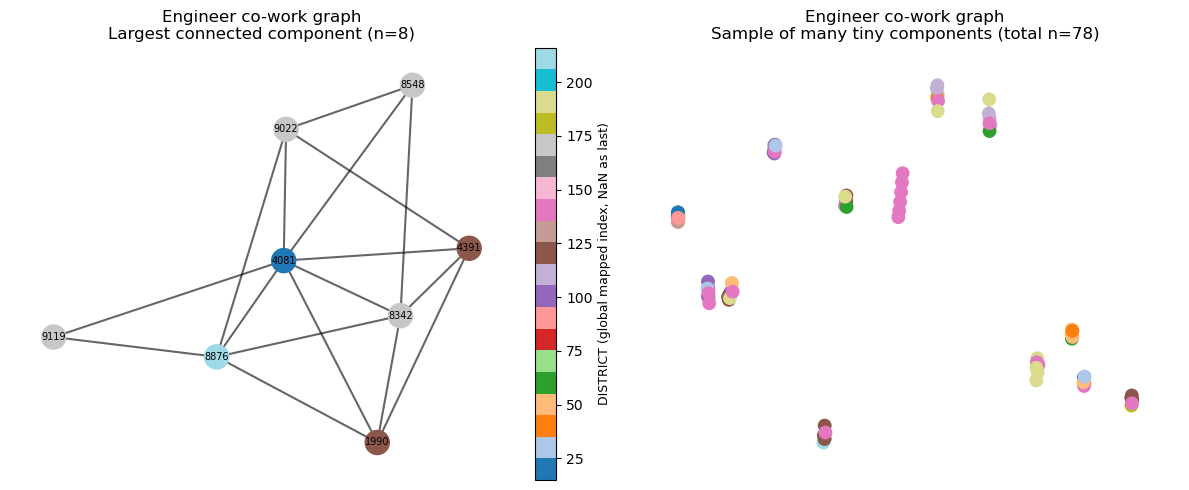

In [ ]:
import torch
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


def build_undirected_graph(edge_index: torch.Tensor, num_nodes: int) -> nx.Graph:
    ei = edge_index.cpu().numpy()
    src, dst = ei
    G = nx.Graph()
    G.add_nodes_from(range(num_nodes))
    G.add_edges_from(zip(src.tolist(), dst.tolist()))
    return G



x_eng = data["engineers"].x           # [N_eng, F]
edge_index = edge_index_eng.to(x_eng.device)

G = build_undirected_graph(edge_index, num_nodes=x_eng.shape[0])

# 所有连通块
components = list(nx.connected_components(G))
components_sorted = sorted(components, key=len, reverse=True)

# 最大连通块（左图）
lcc_nodes = sorted(list(components_sorted[0]))
G_lcc = G.subgraph(lcc_nodes).copy()


max_nodes_small = 80  
small_comps = []
total_nodes = 0
for comp in components_sorted[1:]:
    comp = list(comp)
    if total_nodes + len(comp) > max_nodes_small:
        break
    small_comps.append(comp)
    total_nodes += len(comp)

small_nodes = sorted({n for comp in small_comps for n in comp})
G_small = G.subgraph(small_nodes).copy()

print(f"LCC size: {len(lcc_nodes)}, small-components total nodes: {len(small_nodes)}")



district_full = engineer_feat_clean["DISTRICT"].to_numpy()


mask_not_nan = ~pd.isna(district_full)
uniq_districts = sorted(set(district_full[mask_not_nan]))
d2idx_global = {d: i for i, d in enumerate(uniq_districts)}
nan_color_idx = len(uniq_districts)  

def get_node_districts_global(G_sub: nx.Graph):
    nodes = sorted(G_sub.nodes())
    districts = district_full[nodes]

    color_idx = []
    for d in districts:
        if pd.isna(d):
            color_idx.append(nan_color_idx)
        else:
            color_idx.append(d2idx_global[d])
    return nodes, districts, color_idx

nodes_lcc, districts_lcc, color_idx_lcc = get_node_districts_global(G_lcc)
nodes_small, districts_small, color_idx_small = get_node_districts_global(G_small)


# ========= 3. 画两个 graph 在一张图里 =========
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- 左图：LCC ----
ax = axes[0]
pos_lcc = nx.spring_layout(G_lcc, seed=0)

sc_lcc = nx.draw_networkx_nodes(
    G_lcc,
    pos_lcc,
    nodelist=nodes_lcc,
    node_color=color_idx_lcc,
    cmap="tab20",
    node_size=300,
    ax=ax,
)
nx.draw_networkx_edges(G_lcc, pos_lcc, alpha=0.6, width=1.5, ax=ax)
nx.draw_networkx_labels(G_lcc, pos_lcc, font_size=7, ax=ax)

ax.set_title(f"Engineer co-work graph\nLargest connected component (n={len(nodes_lcc)})")
ax.axis("off")

cbar = plt.colorbar(sc_lcc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("DISTRICT (global mapped index, NaN as last)", fontsize=9)

# ---- 右图：若干小连通块 ----
ax = axes[1]

pos_small_raw = nx.spring_layout(G_small, seed=1)
pos_small = {}
offset = 0.0
for comp in small_comps:
    comp = sorted(comp)
    sub_pos = {n: pos_small_raw[n] for n in comp}
    for n in comp:
        x, y = sub_pos[n]
        pos_small[n] = (x + offset, y)
    offset += 2.0  # 连通块之间拉开一点

sc_small = nx.draw_networkx_nodes(
    G_small,
    pos_small,
    nodelist=nodes_small,
    node_color=color_idx_small,
    cmap="tab20",
    node_size=80,
    ax=ax,
)
nx.draw_networkx_edges(G_small, pos_small, alpha=0.4, width=1.0, ax=ax)

ax.set_title(f"Engineer co-work graph\nSample of many tiny components (total n={len(nodes_small)})")
ax.axis("off")

plt.tight_layout()


plt.show()


[before node sampling] nodes=698, edges=400
Final demo graph: 698 nodes, 400 edges


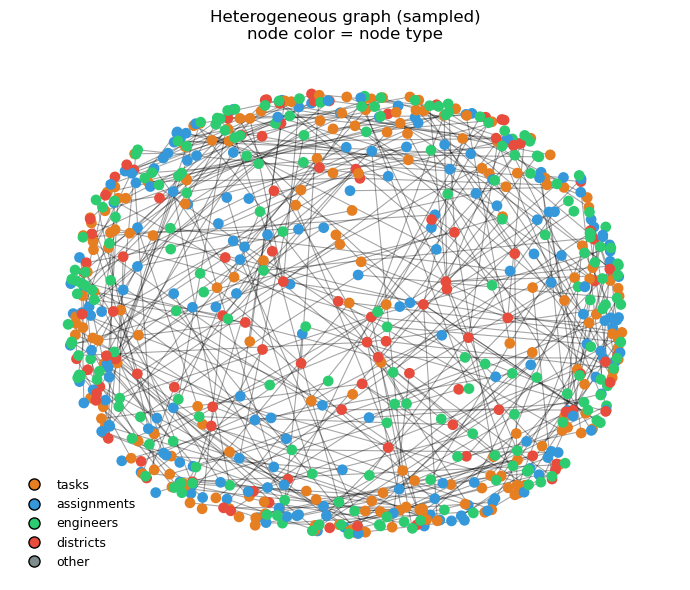

In [40]:
import torch
import random
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ========== 1. 从 HeteroData 里抽个小图出来 ==========

def build_sampled_hetero_graph(
    data,
    max_edges_per_type: int = 8,
    max_nodes: int | None = 80,
    seed: int = 0,
) -> nx.Graph:
    """
    从 HeteroData 里抽一个小异构图做示意：
      - 节点形如 (ntype, local_idx)
      - 每种 edge type 最多抽 max_edges_per_type 条
      - 若节点数 > max_nodes，则随机抽 max_nodes 个节点做诱导子图
    """
    random.seed(seed)
    g = nx.Graph()

    # 1) 按 edge_type 抽一部分边
    for (src_type, rel, dst_type) in data.edge_types:
        edge_index = data[(src_type, rel, dst_type)].edge_index
        E = edge_index.shape[1]
        if E == 0:
            continue

        if E > max_edges_per_type:
            idx = torch.randperm(E)[:max_edges_per_type]
            ei = edge_index[:, idx]
        else:
            ei = edge_index

        src_nodes = ei[0].tolist()
        dst_nodes = ei[1].tolist()

        for s, d in zip(src_nodes, dst_nodes):
            u = (src_type, int(s))
            v = (dst_type, int(d))
            g.add_node(u, ntype=src_type)
            g.add_node(v, ntype=dst_type)
            g.add_edge(u, v, rel=rel)

    print(f"[before node sampling] nodes={g.number_of_nodes()}, edges={g.number_of_edges()}")

    # 2) 节点太多的话，再随机抽一部分节点
    if max_nodes is not None and g.number_of_nodes() > max_nodes:
        all_nodes = list(g.nodes())
        keep_nodes = set(random.sample(all_nodes, max_nodes))
        g = g.subgraph(keep_nodes).copy()
        print(f"[after node sampling] nodes={g.number_of_nodes()}, edges={g.number_of_edges()}")

    return g


G_demo = build_sampled_hetero_graph(
    data,
    max_edges_per_type=50,   # 再小都行，比如 5
    max_nodes=3000,           # 小一点图好看一点
    seed=0,
)

print(f"Final demo graph: {G_demo.number_of_nodes()} nodes, {G_demo.number_of_edges()} edges")


# ========== 2. 颜色按 node type 区分 ==========

type_to_color = {
    "tasks":       "#E67E22",  # 橙
    "assignments": "#3498DB",  # 蓝
    "engineers":   "#2ECC71",  # 绿
    "districts":   "#E74C3C",  # 红
}
default_color = "#7F8C8D"

nodes = list(G_demo.nodes())
ntypes = [G_demo.nodes[n].get("ntype", "other") for n in nodes]
colors = [type_to_color.get(t, default_color) for t in ntypes]


# ========== 3. 画示意图 ==========

plt.figure(figsize=(7, 6))

pos = nx.spring_layout(G_demo, seed=0, k=0.5)

nx.draw_networkx_edges(
    G_demo,
    pos,
    alpha=0.35,
    width=0.8,
)

nx.draw_networkx_nodes(
    G_demo,
    pos,
    nodelist=nodes,
    node_color=colors,
    node_size=45,
)

plt.axis("off")
plt.title("Heterogeneous graph (sampled)\nnode color = node type", fontsize=12)

legend_elements = []
for t, c in type_to_color.items():
    legend_elements.append(
        Line2D([0], [0], marker='o', color='none',
               markerfacecolor=c, markersize=8, label=t)
    )
if default_color:
    legend_elements.append(
        Line2D([0], [0], marker='o', color='none',
               markerfacecolor=default_color, markersize=8, label="other"),
    )

plt.legend(handles=legend_elements, loc="lower left", fontsize=9, frameon=False)
plt.tight_layout()

# 存图的话就开这两行
# from pathlib import Path
# Path("data/graph").mkdir(parents=True, exist_ok=True)
# plt.savefig("data/graph/hetero_graph_demo_small.png", dpi=300)

plt.show()
